## Extract everyday-life number situations questionnaire (`numSituations_alltag`)

Reads sheet `numSituations_alltag` from `add_measure_1/2/3.xlsx`.
Participants are split across the 3 files (file 1: sub 0–22, file 2: sub 23–45, file 3: sub 46–66).

Saves to `derivatives/phenotype/everyday_life_numSituations.csv` with columns:
- `item_01` … `item_14` — individual Likert scores (1–5)
- `mean_score` — mean across all 14 items

### Item labels
| item | German original | English translation |
|------|-----------------|---------------------|
| item_01 | Ich versuche es aktiv zu vermeiden passend mit Bargeld zu zahlen | I actively try to avoid paying with exact change in cash |
| item_02 | Wenn ich mit Freunden offene Rechnungen habe … überlasse ich den anderen die Verteilung der Kosten | When splitting bills with friends, I leave the calculation of costs to others |
| item_03 | Es fällt mir schwer den endgültigen Preis im Ausverkauf/Sales zu bestimmen | I find it difficult to determine the final discounted price during a sale |
| item_04 | Mein Monatsbudget im Überblick zu halten empfinde ich als besonders schwer | I find it particularly hard to keep track of my monthly budget |
| item_05 | Die Umrechnung in andere Währungen empfinde ich als extrem kompliziert | Converting to other currencies feels extremely complicated to me |
| item_06 | Zeitplanung fällt mir schwer | Planning my time is difficult for me |
| item_07 | In zeitlich begrenzten Situationen habe ich Angst die verbleibende Zeit nicht gut einschätzen zu können | In time-pressured situations, I am afraid of not being able to judge the remaining time well |
| item_08 | Meine generelle Unsicherheit bei der Einschätzung von Zeit sorgt dafür, dass ich anders plane | My general uncertainty about estimating time causes me to plan differently than others |
| item_09 | Sobald Zahlen in einer Situation im Alltag involviert sind, bekomme ich Angst, etwas falsch machen zu können | As soon as numbers are involved in an everyday situation, I am afraid of making a mistake |
| item_10 | Ich kann mir Zahlenreihen (z.B. Telefonnummer, Pins) sehr schwer merken | I find it very hard to memorize sequences of numbers (e.g., phone numbers, PINs) |
| item_11 | Ich finde es schwer Geschwindigkeiten in Verkehrssituationen einzuschätzen | I find it difficult to judge speeds in traffic situations |
| item_12 | Ich traue mich nicht einfache Kalkulationen im Kopf zu machen | I don't trust myself to do simple calculations in my head |
| item_13 | Es fällt mir schwer Längen/Höhen/Entfernungen einzuschätzen | I find it difficult to estimate lengths, heights, or distances |
| item_14 | Das Umrechnen von verschiedenen Einheiten eines Masses verwirrt mich | Converting between different units of measurement confuses me |

In [1]:
import pandas as pd
import numpy as np
import os.path as op

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
target_folder = op.join(bids_folder, 'derivatives', 'phenotype')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def extract_alltag(filepath):
    """Extract numSituations_alltag sheet → DataFrame (subjects × 14 items)."""
    df = pd.read_excel(filepath, sheet_name='numSituations_alltag', header=None)

    # Subject IDs are in row 2 (file 1) or row 3 (files 2/3), starting at col 2
    # Detect by finding the first row at index 2 or 3 where col 2 is numeric
    sub_row = None
    for idx in [2, 3]:
        if pd.notna(df.iloc[idx, 2]) and isinstance(df.iloc[idx, 2], (int, float)):
            sub_row = idx
            break

    # Subject IDs and which columns they occupy
    sub_series = df.iloc[sub_row, 2:].dropna()
    sub_ids = sub_series.astype(int).values
    sub_cols = sub_series.index.tolist()

    # Question rows: col 1 is not NaN and not the header label 'Frage'
    after_header = df.iloc[sub_row + 1:]
    q_rows = after_header[after_header[1].notna() & (after_header[1] != 'Frage')]

    # Extract numeric scores (coerce comments/text to NaN)
    scores = q_rows[sub_cols].apply(pd.to_numeric, errors='coerce').values  # shape: (n_items, n_subs)

    item_labels = [f'item_{i:02d}' for i in range(1, scores.shape[0] + 1)]
    result = pd.DataFrame(scores.T, index=sub_ids, columns=item_labels)
    result.index.name = 'subject'
    return result

In [3]:
tab_1 = extract_alltag(op.join(bids_folder, 'add_tables', 'add_measure_1.xlsx'))
tab_2 = extract_alltag(op.join(bids_folder, 'add_tables', 'add_measure_2.xlsx'))
tab_3 = extract_alltag(op.join(bids_folder, 'add_tables', 'add_measure_3.xlsx'))

# subject 46 appears at end of file 2 and start of file 3 — keep file 3 entry
tab_2 = tab_2.drop(index=46, errors='ignore')
tab_1 = tab_1.drop(index=0, errors='ignore') # subject 0 is not included in the final dataset

df = pd.concat([tab_1, tab_2, tab_3], axis=0).sort_index()
print(f'{len(df)} subjects, {df.shape[1]} items')
df.head()

66 subjects, 14 items


,item_01,item_02,item_03,item_04,item_05,item_06,item_07,item_08,item_09,item_10,item_11,item_12,item_13,item_14
subject,,,,,,,,,,,,,,
1,4.0,3.0,2.0,1.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,3.0,3.0,2.0
2,2.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0,5.0,3.0,5.0,5.0,5.0
3,1.0,4.0,2.0,1.0,4.0,1.0,4.0,4.0,5.0,1.0,1.0,1.0,1.0,3.0
4,5.0,4.0,5.0,1.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,4.0,4.0,3.0
5,5.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,2.0


In [4]:
df['mean_score'] = df.mean(axis=1)
df.head()

,item_01,item_02,item_03,item_04,item_05,item_06,item_07,item_08,item_09,item_10,item_11,item_12,item_13,item_14,mean_score
subject,,,,,,,,,,,,,,,
1,4.0,3.0,2.0,1.0,4.0,1.0,1.0,1.0,1.0,2.0,2.0,3.0,3.0,2.0,2.142857
2,2.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,4.0,5.0,3.0,5.0,5.0,5.0,4.428571
3,1.0,4.0,2.0,1.0,4.0,1.0,4.0,4.0,5.0,1.0,1.0,1.0,1.0,3.0,2.357143
4,5.0,4.0,5.0,1.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,4.0,4.0,3.0,3.214286
5,5.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,2.0,1.714286


In [5]:
# check for group differences!
df_participants = pd.read_csv(op.join('/Users/mrenke/data/ds-dnumrisk/add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
df_participants = df_participants.loc[:,['subject ID', 'age','group','gender']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
df_participants['group'] = np.where(df_participants['group'] == 0, 'control', 'dyscalc')

tmp = df.join(df_participants['group'], on='subject', how='inner')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_

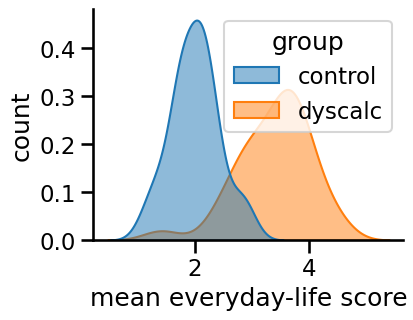

In [6]:
# quick sanity check: score distributions
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

fig, ax = plt.subplots(figsize=(4, 3))
sns.kdeplot(data=tmp, x='mean_score',ax=ax, hue='group', fill=True, alpha=0.5)
ax.set(xlabel='mean everyday-life score', ylabel='count')
sns.despine()

In [ ]:
#df.to_csv(op.join(target_folder, 'everyday_life_numSituations.csv'))
print('saved to', op.join(target_folder, 'everyday_life_numSituations.csv'))

saved to /Users/mrenke/data/ds-dnumrisk/derivatives/phenotype/everyday_life_numSituations.csv


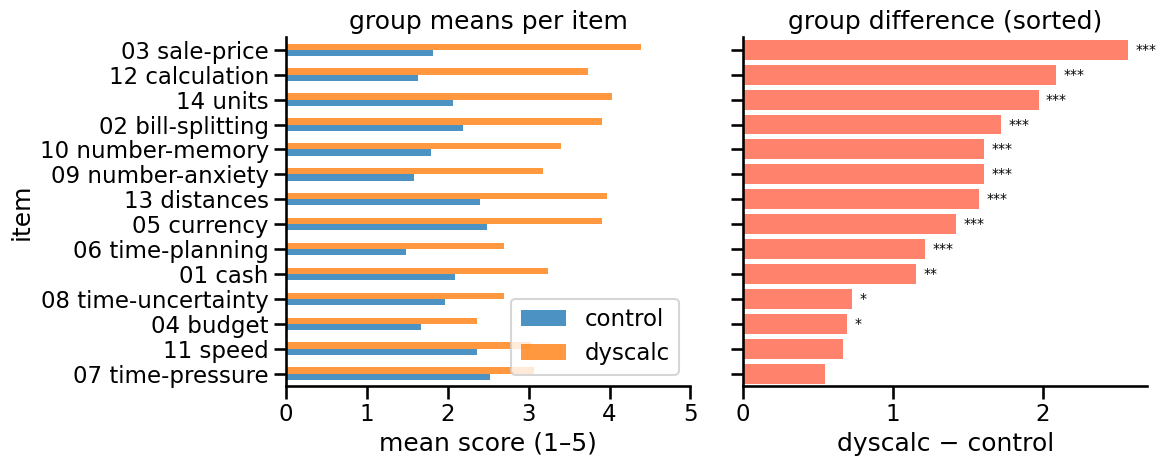

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [7]:
import pingouin as pg

item_cols = [c for c in df.columns if c.startswith('item_')]

short_labels = {
    'item_01': '01 cash',           'item_02': '02 bill-splitting',  'item_03': '03 sale-price',
    'item_04': '04 budget',         'item_05': '05 currency',        'item_06': '06 time-planning',
    'item_07': '07 time-pressure',  'item_08': '08 time-uncertainty','item_09': '09 number-anxiety',
    'item_10': '10 number-memory',  'item_11': '11 speed',           'item_12': '12 calculation',
    'item_13': '13 distances',      'item_14': '14 units',
}

rows = []
for item in item_cols:
    g0 = tmp.loc[tmp['group'] == 'control', item].dropna()
    g1 = tmp.loc[tmp['group'] == 'dyscalc', item].dropna()
    t = pg.ttest(g1, g0)
    rows.append({
        'item': short_labels[item],
        'mean_control': g0.mean(),
        'mean_dyscalc': g1.mean(),
        'diff': g1.mean() - g0.mean(),
        'p': t['p-val'].values[0],
        'd': t['cohen-d'].values[0],
    })

stats = pd.DataFrame(rows).set_index('item').sort_values('diff', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.set_context('talk')

# left: group means per item
stats[['mean_control', 'mean_dyscalc']].plot.barh(
    ax=axes[0], color=[sns.color_palette()[0], sns.color_palette()[1]], alpha=0.8)
axes[0].set(xlabel='mean score (1–5)', title='group means per item', xlim=(0, 5))
axes[0].legend(['control', 'dyscalc'])

# right: difference (dyscalc − control) with significance markers
colors = ['tomato' if d > 0 else 'steelblue' for d in stats['diff']]
axes[1].barh(stats.index, stats['diff'], color=colors, alpha=0.8)
axes[1].axvline(0, color='k', lw=0.8)
for i, (_, row) in enumerate(stats.iterrows()):
    marker = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else ''))
    if marker:
        offset = 0.05 if row['diff'] >= 0 else -0.05
        axes[1].text(row['diff'] + offset, i, marker, va='center', fontsize=10)
axes[1].set(xlabel='dyscalc − control', title='group difference (sorted)')

sns.despine()
plt.tight_layout()